In [111]:
# --- Important basique ---------------------------------------------
import kagglehub
from kagglehub import KaggleDatasetAdapter
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
file_path = "healthcare-dataset-stroke-data.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "fedesoriano/stroke-prediction-dataset",
    file_path,
).copy()

# --- Separation des donnees ---------------------------------------------
from sklearn.model_selection import train_test_split, GridSearchCV

# --- Preprocessing -------------------------------------------------------
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# --- Modeles -------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# --- Evaluation ----------------------------------------------------------
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)

# --- Sauvegarde ----------------------------------------------------------
import joblib
RANDOM_STATE = 42
print("Imports OK")



Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Imports OK


In [101]:
#exploration rapide du df
print("taille de df : ", df.shape)
print(df.head())
print(df.info())
print(df.duplicated().sum())
print(df.describe(include="all").T)

taille de df :  (5110, 12)
      id  gender   age  hypertension  heart_disease ever_married      work_type Residence_type  avg_glucose_level   bmi   smoking_status  stroke
0   9046    Male  67.0             0              1          Yes        Private          Urban             228.69  36.6  formerly smoked       1
1  51676  Female  61.0             0              0          Yes  Self-employed          Rural             202.21   NaN     never smoked       1
2  31112    Male  80.0             0              1          Yes        Private          Rural             105.92  32.5     never smoked       1
3  60182  Female  49.0             0              0          Yes        Private          Urban             171.23  34.4           smokes       1
4   1665  Female  79.0             1              0          Yes  Self-employed          Rural             174.12  24.0     never smoked       1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 column

In [103]:
#Étape 1 — Cadrage du dataset : définir X/y
y = df['stroke']
X = df.drop('stroke',axis =1)
print(X.shape,y.shape)
print(X.isna().sum())
print(X.isna().sum().sum())
print(y.value_counts())
print(y.value_counts(normalize=True))

(5110, 11) (5110,)
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
dtype: int64
201
stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64


In [104]:
print(X.dtypes.to_dict())
X = X.drop(columns=['id'], axis=1,errors='ignore')

{'id': dtype('int64'), 'gender': dtype('O'), 'age': dtype('float64'), 'hypertension': dtype('int64'), 'heart_disease': dtype('int64'), 'ever_married': dtype('O'), 'work_type': dtype('O'), 'Residence_type': dtype('O'), 'avg_glucose_level': dtype('float64'), 'bmi': dtype('float64'), 'smoking_status': dtype('O')}


In [105]:
list_features = X.columns.to_list()
print(list_features)
print(f'nb de feautres : {len(list_features)}')

['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']
nb de feautres : 10


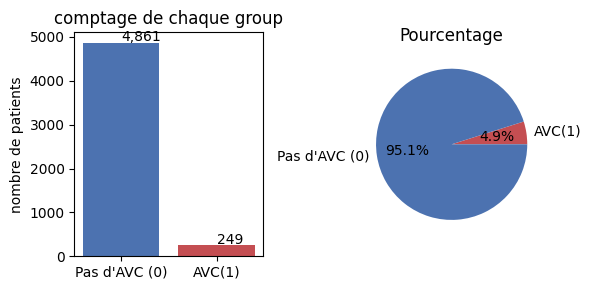

In [106]:
counts = y.value_counts().sort_index()
rate = y.mean()

BLUE = '#4C72B0'
ROUGE = '#C44E52'

fig, ax = plt.subplots(1, 2, figsize=(6, 3))

ax[0].bar(["Pas d'AVC (0)", "AVC(1)"], counts.values, color=[BLUE, ROUGE])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 40, f'{v:,}')
ax[0].set_title('comptage de chaque group');
ax[0].set_ylabel('nombre de patients')

ax[1].pie([rate,1-rate], labels=["AVC(1)","Pas d'AVC (0)"],colors=[ROUGE,BLUE], autopct='%1.1f%%')
ax[1].set_title('Pourcentage')

plt.tight_layout()
plt.savefig('distribution_classes.png', bbox_inches='tight')
plt.show()

Étape 2 — Split, preprocessing et pipeline :
Travail attendu :
Split train/val/test
ColumnTransformer adapté
Assemblage dans une Pipeline



In [109]:
#Étape 2 — Split en 3 partie

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,test_size=0.25, random_state=42,stratify=y_temp
)


In [110]:
#preprocessing et pipeline

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.to_list()
cat_cols = X_train.select_dtypes(include="object").columns.to_list()

pipeline_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

pipeline_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder",  OneHotEncoder(handle_unknown='ignore',sparse_output=False)),
])

preprocesseur = ColumnTransformer(
    transformers=[
        ("num", pipeline_num,num_cols),
        ("cat", pipeline_cat,cat_cols),
    ],
    remainder="drop",  #les colonnes non citees sont supprimees
)

pipeline = Pipeline(
    [
        ("preprocessing", preprocesseur),
        (
            "modele",
            RandomForestClassifier(random_state=RANDOM_STATE)),
    ]
)
pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'hypertension',
                                                   'heart_disease',
                                                   'avg_glucose_level',
                                                   'bmi']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status'])])),
                ('modele', RandomForestClassifier(random_state=42))])

In [108]:
print(num_cols)
print(cat_cols)

['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


Étape 3 — Grille de modèles candidats :
Travail attendu :
param_grid avec ≥2 modèles candidats et une métrique justifiée.


In [93]:
# 3 modèle : Logistic Regression, Random Forest,Decision Tree,
param_grid = [
    #Logistic Regression
    {
        "modele":    [LogisticRegression(class_weight="balanced",max_iter=5000, random_state=42)],
        "modele__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    },
    # Random Forest
    {
        "modele":                   [RandomForestClassifier(class_weight="balanced",random_state=42)],
        "modele__n_estimators":     [100, 200],
        "modele__max_depth":        [None, 5, 10],
        "modele__min_samples_leaf": [1, 5],
    },
    # Decision Tree
    {
        "modele":                   [DecisionTreeClassifier(class_weight="balanced",random_state=42)],
        "modele__max_depth":        [None, 5, 10],
        "modele__min_samples_leaf": [1, 5, 10],
    },
]

grille = GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    cv=5,
    n_jobs=1,
    scoring = ['accuracy','recall','f1','roc_auc'],
    refit='recall',
)

grille.fit(X_train, y_train)

print("Training finished")
print("Meilleur score (recall):", grille.best_score_)
print("Meilleurs paramètres:", grille.best_params_)


Training finished
Meilleur score (recall): 0.799080459770115
Meilleurs paramètres: {'modele': LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42), 'modele__C': 0.01}


Étape 4 — Entraînement, évaluation, sauvegarde :
Travail attendu :
GridSearchCV sur le train
Évaluation validation puis test (une seule fois)
Sauvegarde joblib


In [116]:
print("Modele retenu :", grille.best_params_["modele"].__class__.__name__)

print("\nSes hyperparametres :")
for nom, valeur in grille.best_params_.items():
    if nom != "modele":
        print(f"{nom:<15} = {valeur}")

print(f"\nMeilleur score en validation croisee : {grille.best_score_:.3f}")

meilleur_modele = grille.best_estimator_

Modele retenu : LogisticRegression

Ses hyperparametres :
modele__C       = 0.01

Meilleur score en validation croisee : 0.799


In [123]:
y_val_pred = meilleur_modele.predict(X_val)
y_val_proba = meilleur_modele.predict_proba(X_val)[:, 1]

print("=== Évaluation sur VALIDATION ===")
print(classification_report(y_val, y_val_pred, target_names=["Pas d'AVC", "AVC"]))
print(f"ROC-AUC_validation :, {roc_auc_score(y_val, y_val_proba):.3f}")
print("Matrice de confusion :\n", confusion_matrix(y_val, y_val_pred))

=== Évaluation sur VALIDATION ===
              precision    recall  f1-score   support

   Pas d'AVC       0.99      0.73      0.84       972
         AVC       0.14      0.84      0.24        50

    accuracy                           0.74      1022
   macro avg       0.56      0.79      0.54      1022
weighted avg       0.95      0.74      0.81      1022

ROC-AUC_validation :, 0.845
Matrice de confusion :
 [[713 259]
 [  8  42]]


In [124]:
y_test_pred = meilleur_modele.predict(X_test)
y_test_proba = meilleur_modele.predict_proba(X_test)[:, 1]

print("=== Évaluation sur TEST (une seule fois) ===")
print(classification_report(y_test, y_test_pred, target_names=["Pas d'AVC", "AVC"]))
print(f"ROC-AUC_test :, {roc_auc_score(y_test, y_test_proba):.3f}")
print("Matrice de confusion :\n", confusion_matrix(y_test, y_test_pred))

=== Évaluation sur TEST (une seule fois) ===
              precision    recall  f1-score   support

   Pas d'AVC       0.99      0.74      0.84       972
         AVC       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022

ROC-AUC_test :, 0.841
Matrice de confusion :
 [[715 257]
 [ 10  40]]


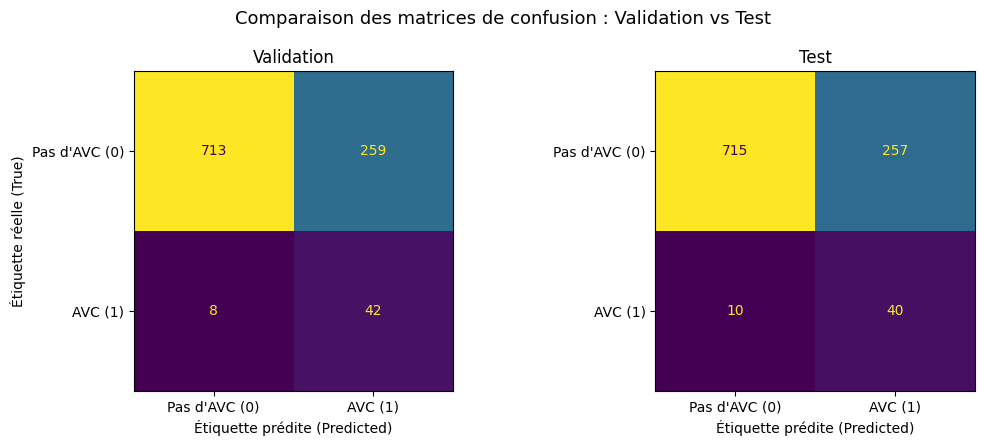

In [126]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# --- Matrice de confusion : VALIDATION ---
cm_val = confusion_matrix(y_val, y_val_pred)
disp_val = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=["Pas d'AVC (0)", "AVC (1)"],
)
disp_val.plot(values_format="d", ax=axes[0], colorbar=False)
axes[0].set_title("Validation")
axes[0].set_xlabel("Étiquette prédite (Predicted)")
axes[0].set_ylabel("Étiquette réelle (True)")

# --- Matrice de confusion : TEST ---
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["Pas d'AVC (0)", "AVC (1)"],
)
disp_test.plot(values_format="d", ax=axes[1], colorbar=False)
axes[1].set_title("Test")
axes[1].set_xlabel("Étiquette prédite (Predicted)")
axes[1].set_ylabel("")  # éviter la répétition du label y sur le 2e graphe

fig.suptitle("Comparaison des matrices de confusion : Validation vs Test", fontsize=13)
plt.tight_layout()
plt.savefig("matrice_confusion_val_test.png", bbox_inches="tight")
plt.show()

In [120]:
joblib.dump(meilleur_modele, "pipeline_stroke_prediction.joblib")
print("Pipeline sauvegardée avec succès ✅")

Pipeline sauvegardée avec succès ✅


Étape 5 — Synthèse pour la responsable de mission :

Synthèse ~1 page : problème, modèle retenu, performance, limites, recommandation.
